# Tugas Analisis Multimedia: Image (Citra Digital)

**Mata Kuliah:** Pengolahan Citra  
**Nama:** Rinto Bagus Pratama  
**NIM:** 123400017  
**Repository GitHub:** https://github.com/Rinto017/Pengolahan_Multimedia

Notebook ini berisi penyelesaian Worksheet 4 tentang representasi citra digital, manipulasi channel warna, deteksi tepi, filter citra, overlay filter wajah, dan koreksi perspektif.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Folder input dan output
ASSETS_DIR = 'assets_ws4'
RESULTS_DIR = 'results_ws4'
os.makedirs(ASSETS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Path gambar yang digunakan
selfie_path = os.path.join(ASSETS_DIR, 'selfie.jpg')
objek_path = os.path.join(ASSETS_DIR, 'objek_tekstur.jpg')
kertas_path = os.path.join(ASSETS_DIR, 'kertas_miring.jpg')

print('Folder assets:', ASSETS_DIR)
print('Folder results:', RESULTS_DIR)
print('Cek selfie:', os.path.exists(selfie_path))
print('Cek objek tekstur:', os.path.exists(objek_path))
print('Cek kertas miring:', os.path.exists(kertas_path))

Folder assets: assets_ws4
Folder results: results_ws4
Cek selfie: True
Cek objek tekstur: True
Cek kertas miring: True


## Soal 1 - Cropping dan Konversi Warna

Pada soal ini digunakan foto diri sebagai citra utama. Area wajah dipotong secara manual dalam bentuk persegi, sedangkan area latar belakang dipotong dalam bentuk persegi panjang. Hasil crop kemudian diubah ukurannya menjadi 920 x 920 piksel. Setelah itu, citra dikonversi ke grayscale dan HSV untuk membandingkan perbedaan representasi warna.

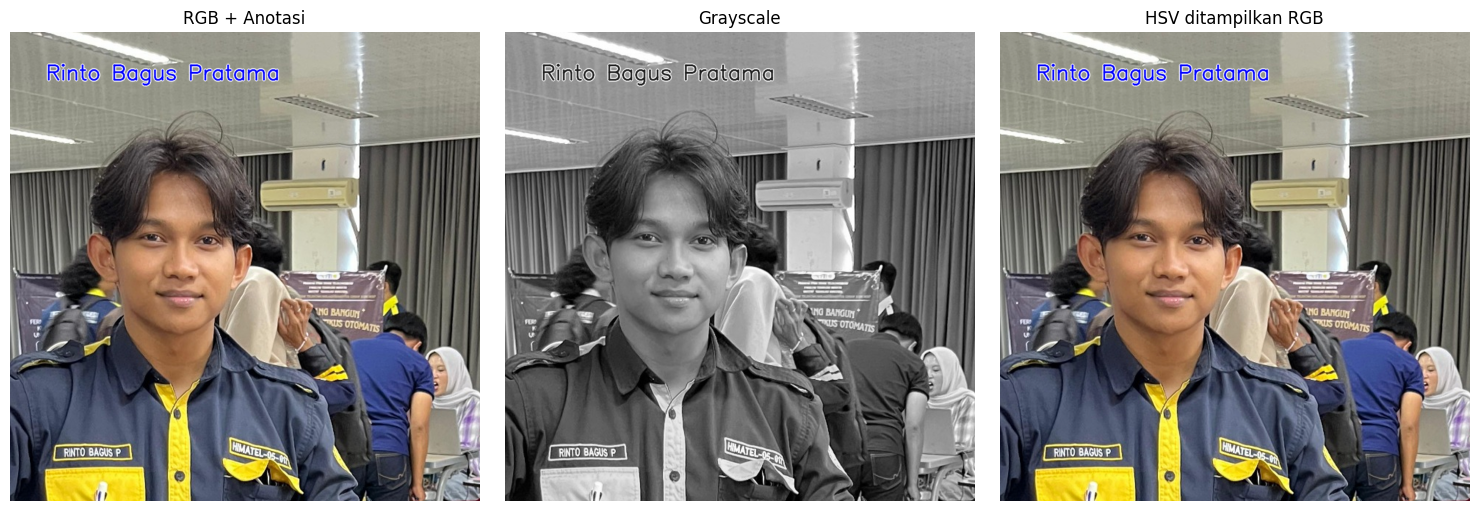

In [2]:
# Load gambar selfie
img_bgr = cv2.imread(selfie_path)
if img_bgr is None:
    raise FileNotFoundError('Gambar selfie tidak ditemukan. Pastikan selfie.jpg ada di assets_ws4')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Crop manual area wajah berbentuk persegi
crop_wajah = img_rgb[180:820, 340:980].copy()
crop_wajah = cv2.resize(crop_wajah, (920, 920), interpolation=cv2.INTER_CUBIC)

# Tambahkan anotasi nama di atas kepala
crop_wajah_annotated = crop_wajah.copy()
cv2.putText(crop_wajah_annotated, 'Rinto Bagus Pratama', (70, 95),
            cv2.FONT_HERSHEY_SIMPLEX, 1.35, (255, 255, 255), 5, cv2.LINE_AA)
cv2.putText(crop_wajah_annotated, 'Rinto Bagus Pratama', (70, 95),
            cv2.FONT_HERSHEY_SIMPLEX, 1.35, (0, 0, 255), 2, cv2.LINE_AA)

# Crop manual area latar belakang berbentuk persegi panjang
crop_background = img_rgb[250:950, 930:1430].copy()
crop_background = cv2.resize(crop_background, (920, 920), interpolation=cv2.INTER_CUBIC)

# Simpan hasil crop
cv2.imwrite(os.path.join(RESULTS_DIR, 'soal1_crop_wajah_annotated.png'),
            cv2.cvtColor(crop_wajah_annotated, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(RESULTS_DIR, 'soal1_crop_background.png'),
            cv2.cvtColor(crop_background, cv2.COLOR_RGB2BGR))

# Konversi ke grayscale dan HSV
gray_wajah = cv2.cvtColor(cv2.cvtColor(crop_wajah_annotated, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2GRAY)
hsv_wajah = cv2.cvtColor(cv2.cvtColor(crop_wajah_annotated, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)
hsv_display = cv2.cvtColor(hsv_wajah, cv2.COLOR_HSV2RGB)

# Tampilkan RGB, Grayscale, dan HSV berdampingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop_wajah_annotated)
axes[0].set_title('RGB + Anotasi')
axes[0].axis('off')

axes[1].imshow(gray_wajah, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

axes[2].imshow(hsv_display)
axes[2].set_title('HSV ditampilkan RGB')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal1_rgb_gray_hsv.png'), dpi=150, bbox_inches='tight')
plt.show()

**Analisis Soal 1:**  
Cropping membuat area yang dianalisis menjadi lebih fokus, terutama pada bagian wajah. Resize ke ukuran 920 x 920 piksel membuat ukuran citra menjadi seragam. Pada citra RGB, informasi warna masih terlihat lengkap. Pada grayscale, warna dihilangkan sehingga hanya tersisa informasi intensitas terang dan gelap. Pada HSV, warna dipisahkan menjadi hue, saturation, dan value sehingga lebih mudah digunakan untuk analisis warna.

## Soal 2 - Manipulasi Channel Warna RGB

Pada soal ini digunakan hasil crop wajah dari Soal 1. Citra dikonversi ke ruang warna RGB, kemudian channel merah dinaikkan sebesar 50 poin dan channel biru diturunkan sebesar 30 poin. Hasilnya disimpan dalam format PNG dan dibandingkan menggunakan histogram per channel.

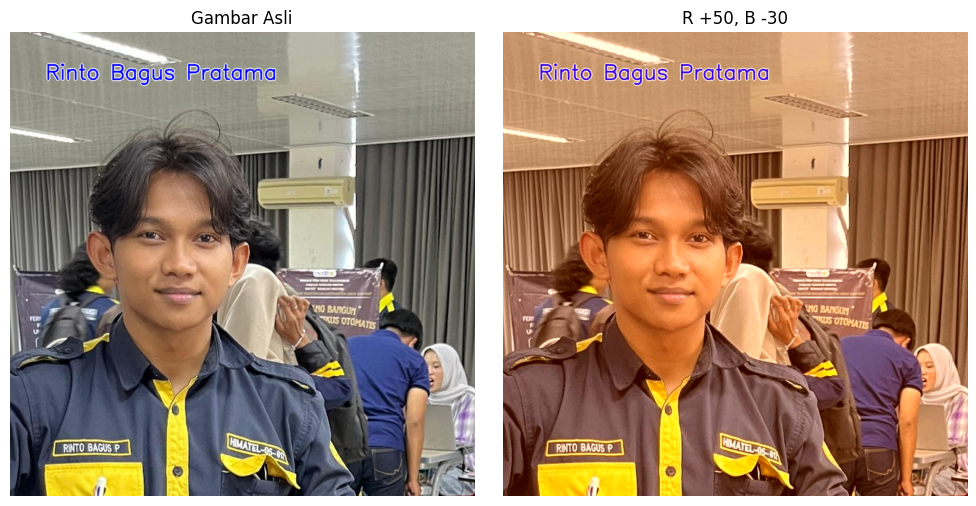

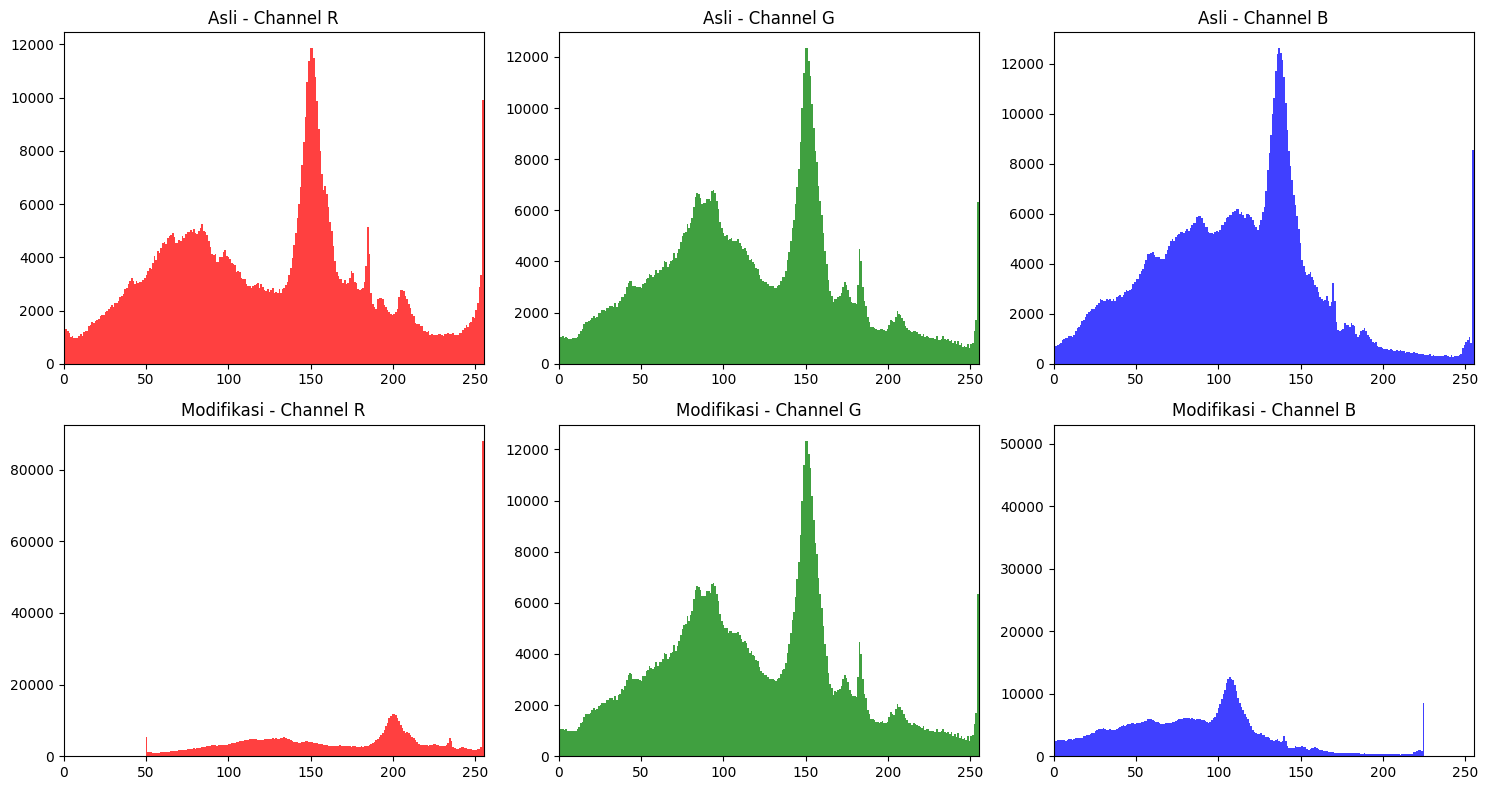

In [3]:
# Gunakan crop wajah hasil Soal 1
original_rgb = crop_wajah_annotated.copy()
modified_rgb = original_rgb.astype(np.int16).copy()

# Manipulasi channel warna
modified_rgb[:, :, 0] = np.clip(modified_rgb[:, :, 0] + 50, 0, 255)  # Red +50
modified_rgb[:, :, 2] = np.clip(modified_rgb[:, :, 2] - 30, 0, 255)  # Blue -30
modified_rgb = modified_rgb.astype(np.uint8)

# Simpan hasil modifikasi
cv2.imwrite(os.path.join(RESULTS_DIR, 'soal2_rgb_modified.png'),
            cv2.cvtColor(modified_rgb, cv2.COLOR_RGB2BGR))

# Tampilkan perbandingan gambar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(original_rgb)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(modified_rgb)
axes[1].set_title('R +50, B -30')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal2_compare_rgb.png'), dpi=150, bbox_inches='tight')
plt.show()

# Histogram channel RGB untuk gambar asli dan modifikasi
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['red', 'green', 'blue']
labels = ['R', 'G', 'B']

for i, (color, label) in enumerate(zip(colors, labels)):
    axes[0, i].hist(original_rgb[:, :, i].ravel(), bins=256, range=(0, 255), color=color, alpha=0.75)
    axes[0, i].set_title(f'Asli - Channel {label}')
    axes[0, i].set_xlim(0, 255)

    axes[1, i].hist(modified_rgb[:, :, i].ravel(), bins=256, range=(0, 255), color=color, alpha=0.75)
    axes[1, i].set_title(f'Modifikasi - Channel {label}')
    axes[1, i].set_xlim(0, 255)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal2_hist_rgb.png'), dpi=150, bbox_inches='tight')
plt.show()

**Analisis Soal 2:**  
Peningkatan channel merah membuat citra terlihat lebih hangat karena komponen warna merah menjadi lebih dominan. Penurunan channel biru mengurangi nuansa dingin pada gambar. Pada histogram, distribusi channel merah bergeser ke kanan karena nilai intensitas meningkat, sedangkan channel biru cenderung menurun karena sebagian nilai intensitas dikurangi.

## Soal 3 - Deteksi Tepi dan Filter Citra

Pada soal ini digunakan gambar objek dengan background meja dan beberapa objek. Proses yang dilakukan meliputi deteksi tepi menggunakan Canny, thresholding untuk memisahkan objek utama, bounding box, serta perbandingan filter blur dan sharpening.

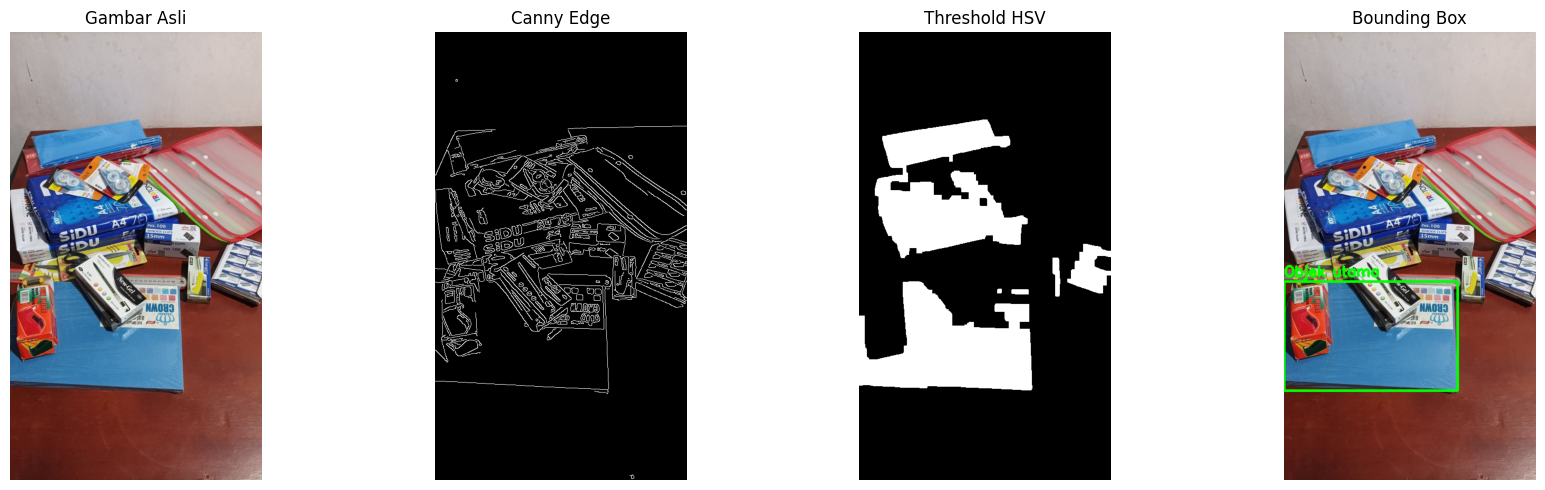

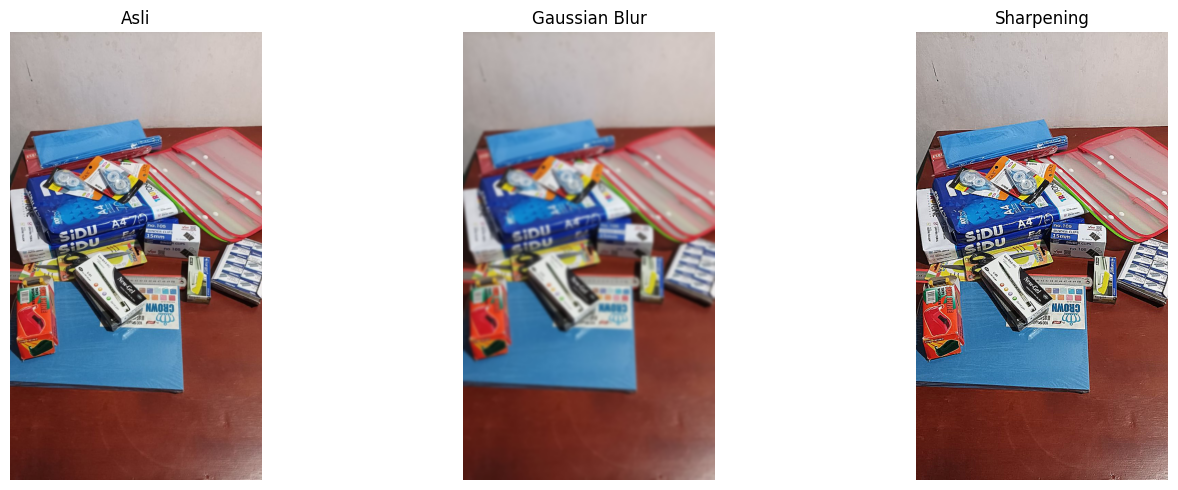

In [4]:
# Load gambar objek bertekstur
obj_bgr = cv2.imread(objek_path)
if obj_bgr is None:
    raise FileNotFoundError('Gambar objek_tekstur.jpg tidak ditemukan di assets_ws4')

# Resize agar visualisasi lebih ringan
obj_bgr = cv2.resize(obj_bgr, None, fx=0.65, fy=0.65, interpolation=cv2.INTER_AREA)
obj_rgb = cv2.cvtColor(obj_bgr, cv2.COLOR_BGR2RGB)

# Grayscale, blur, dan Canny edge detection
gray_obj = cv2.cvtColor(obj_bgr, cv2.COLOR_BGR2GRAY)
blur_obj = cv2.GaussianBlur(gray_obj, (5, 5), 0)
edges = cv2.Canny(blur_obj, 60, 160)

# Thresholding HSV untuk mengambil objek biru sebagai objek utama
hsv_obj = cv2.cvtColor(obj_bgr, cv2.COLOR_BGR2HSV)
lower_blue = np.array([85, 45, 40])
upper_blue = np.array([135, 255, 255])
mask_blue = cv2.inRange(hsv_obj, lower_blue, upper_blue)

# Morfologi untuk memperbaiki mask
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
mask_clean = cv2.morphologyEx(mask_blue, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, kernel, iterations=1)

# Bounding box otomatis dari kontur terbesar
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bbox_img = obj_bgr.copy()

if contours:
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(bbox_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
    cv2.putText(bbox_img, 'Objek utama', (x, max(30, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 3)

# Visualisasi Canny, thresholding, dan bounding box
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(obj_rgb)
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge')
axes[1].axis('off')

axes[2].imshow(mask_clean, cmap='gray')
axes[2].set_title('Threshold HSV')
axes[2].axis('off')

axes[3].imshow(cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB))
axes[3].set_title('Bounding Box')
axes[3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal3_edges_threshold_bbox.png'), dpi=150, bbox_inches='tight')
plt.show()

# Filter blur dan sharpening
blur_color = cv2.GaussianBlur(obj_bgr, (13, 13), 0)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])
sharpen = cv2.filter2D(obj_bgr, -1, kernel_sharp)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(obj_rgb)
axes[0].set_title('Asli')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blur_color, cv2.COLOR_BGR2RGB))
axes[1].set_title('Gaussian Blur')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(sharpen, cv2.COLOR_BGR2RGB))
axes[2].set_title('Sharpening')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal3_filter_compare.png'), dpi=150, bbox_inches='tight')
plt.show()

**Analisis Soal 3:**  
Canny edge detection menampilkan garis tepi dari objek dan background. Karena background memiliki banyak detail, garis tepi yang muncul cukup banyak. Thresholding HSV digunakan untuk memilih objek dengan warna biru sehingga objek utama dapat dipisahkan dari latar. Bounding box kemudian dibuat dari kontur terbesar pada hasil thresholding. Filter blur membuat gambar lebih halus tetapi detail kecil berkurang, sedangkan sharpening memperjelas tepi dan tekstur namun dapat membuat noise terlihat lebih kuat.

## Soal 4 - Deteksi Wajah dan Filter Digital Kreatif

Pada soal ini digunakan deteksi wajah berbasis OpenCV Haar Cascade. Posisi overlay filter ditentukan dari bounding box wajah. Beberapa titik acuan wajah seperti area mata, hidung, dan mulut dihitung secara proporsional dari bounding box. Filter kreatif yang dibuat berupa kacamata hitam, kumis, blush, dan titik acuan wajah.

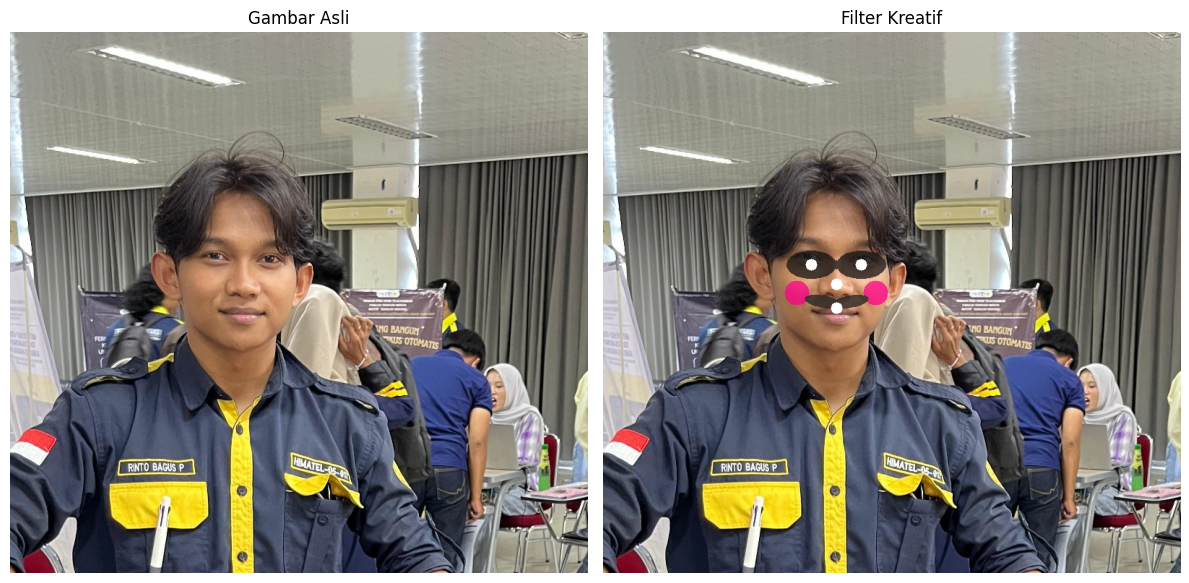

In [5]:
# Load gambar wajah
face_bgr = cv2.imread(selfie_path)
if face_bgr is None:
    raise FileNotFoundError('Gambar selfie.jpg tidak ditemukan di assets_ws4')

# Deteksi wajah menggunakan Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
small = cv2.resize(face_bgr, (0, 0), fx=0.5, fy=0.5)
gray_small = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray_small, scaleFactor=1.08, minNeighbors=5, minSize=(80, 80))

filter_img = face_bgr.copy()

# Jika wajah terdeteksi, gunakan wajah terbesar. Jika tidak, gunakan posisi manual.
if len(faces) > 0:
    fx, fy, fw, fh = max(faces, key=lambda r: r[2] * r[3])
    x, y, w, h = [int(v / 0.5) for v in (fx, fy, fw, fh)]
else:
    x, y, w, h = 385, 245, 500, 600

# Landmark perkiraan berdasarkan bounding box wajah
left_eye = (x + int(0.32 * w), y + int(0.42 * h))
right_eye = (x + int(0.68 * w), y + int(0.42 * h))
nose = (x + int(0.50 * w), y + int(0.56 * h))
mouth = (x + int(0.50 * w), y + int(0.73 * h))

# Overlay filter kreatif
overlay = filter_img.copy()

# Kacamata hitam
cv2.ellipse(overlay, left_eye, (int(0.18 * w), int(0.10 * h)), 0, 0, 360, (20, 20, 20), -1)
cv2.ellipse(overlay, right_eye, (int(0.18 * w), int(0.10 * h)), 0, 0, 360, (20, 20, 20), -1)
cv2.line(overlay, (left_eye[0] + int(0.18 * w), left_eye[1]),
         (right_eye[0] - int(0.18 * w), right_eye[1]), (20, 20, 20), 12)

# Blush pipi
cv2.circle(overlay, (x + int(0.22 * w), y + int(0.62 * h)), int(0.09 * w), (140, 0, 255), -1)
cv2.circle(overlay, (x + int(0.78 * w), y + int(0.62 * h)), int(0.09 * w), (140, 0, 255), -1)

# Kumis
cv2.ellipse(overlay, (mouth[0] - int(0.10 * w), mouth[1] - int(0.05 * h)),
            (int(0.13 * w), int(0.045 * h)), 10, 0, 360, (30, 30, 30), -1)
cv2.ellipse(overlay, (mouth[0] + int(0.10 * w), mouth[1] - int(0.05 * h)),
            (int(0.13 * w), int(0.045 * h)), -10, 0, 360, (30, 30, 30), -1)

# Alpha blending agar natural
filter_img = cv2.addWeighted(overlay, 0.75, filter_img, 0.25, 0)

# Titik acuan/landmark perkiraan
for p in [left_eye, right_eye, nose, mouth]:
    cv2.circle(filter_img, p, 8, (255, 255, 255), -1)

# Crop area wajah untuk perbandingan
crop_original = face_bgr[150:900, 250:1050]
crop_filter = filter_img[150:900, 250:1050]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(crop_original, cv2.COLOR_BGR2RGB))
axes[0].set_title('Gambar Asli')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(crop_filter, cv2.COLOR_BGR2RGB))
axes[1].set_title('Filter Kreatif')
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal4_filter_compare.png'), dpi=150, bbox_inches='tight')
plt.show()

**Analisis Soal 4:**  
Posisi filter dihitung dari bounding box wajah. Titik mata diperkirakan berada pada bagian atas wajah, hidung berada di tengah, dan mulut berada pada bagian bawah wajah. Berdasarkan titik acuan tersebut, kacamata diletakkan di area mata, kumis di sekitar mulut, dan blush di area pipi. Tantangan utama pada proses ini adalah posisi wajah dapat berubah karena jarak, sudut, dan ukuran wajah sehingga posisi overlay harus dibuat proporsional terhadap ukuran bounding box.

## Soal 5 - Perspektif dan Peningkatan Kualitas Citra

Pada soal ini digunakan gambar kertas yang difoto dari sudut tidak ideal. Tahap pemrosesan meliputi konversi grayscale, penentuan empat titik manual, koreksi perspektif menggunakan homografi, dan thresholding Otsu untuk memperjelas tulisan.

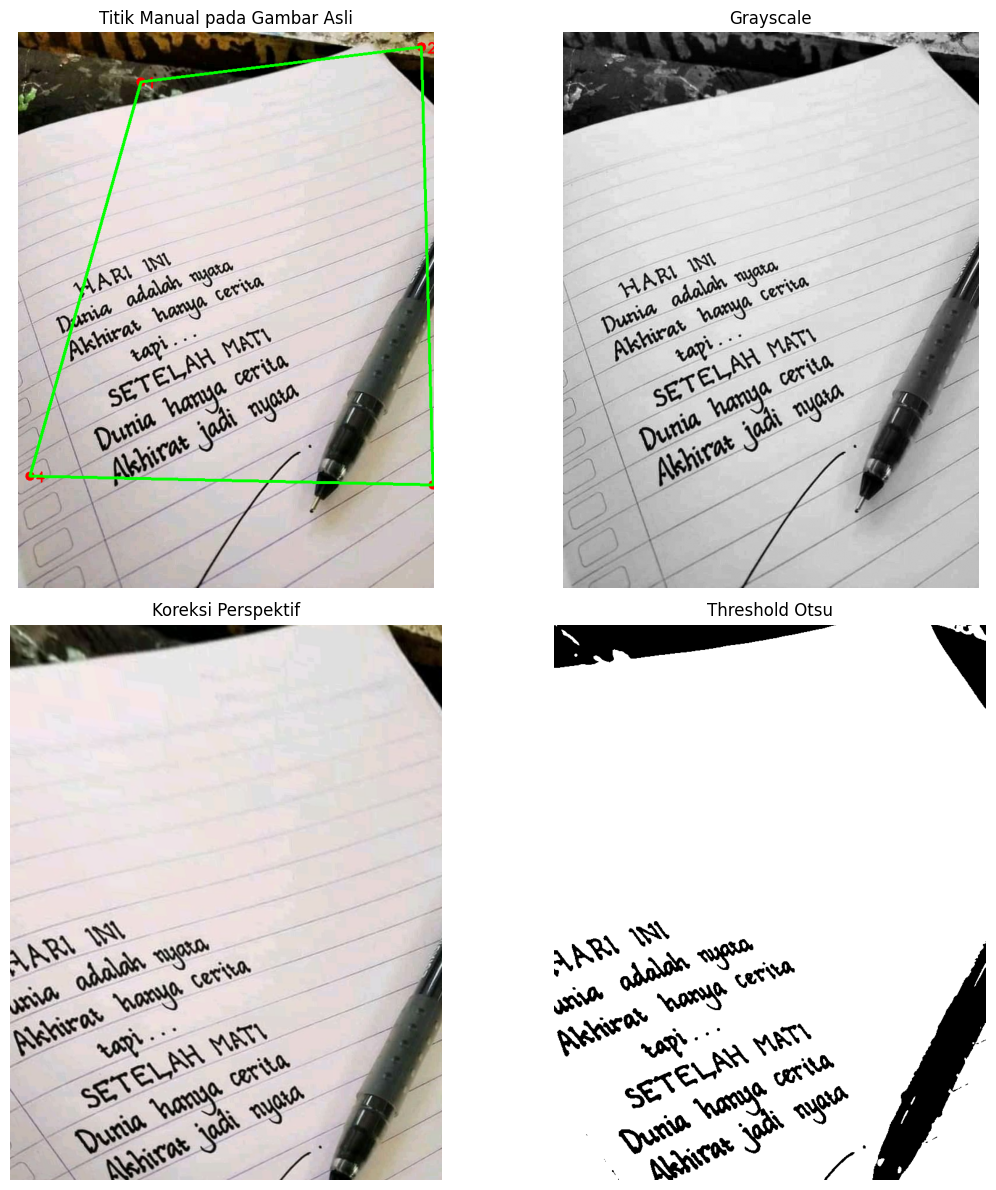

In [6]:
# Load gambar kertas miring
paper_bgr = cv2.imread(kertas_path)
if paper_bgr is None:
    raise FileNotFoundError('Gambar kertas_miring.jpg tidak ditemukan di assets_ws4')

paper_rgb = cv2.cvtColor(paper_bgr, cv2.COLOR_BGR2RGB)

# Empat titik manual: kiri atas, kanan atas, kanan bawah, kiri bawah
pts_src = np.float32([[210, 85], [690, 25], [710, 775], [20, 760]])
W, H = 700, 900
pts_dst = np.float32([[0, 0], [W - 1, 0], [W - 1, H - 1], [0, H - 1]])

# Transformasi perspektif
M = cv2.getPerspectiveTransform(pts_src, pts_dst)
warped = cv2.warpPerspective(paper_bgr, M, (W, H))

# Grayscale
gray_paper = cv2.cvtColor(paper_bgr, cv2.COLOR_BGR2GRAY)
warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

# Thresholding Otsu
warped_blur = cv2.GaussianBlur(warped_gray, (5, 5), 0)
_, otsu = cv2.threshold(warped_blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Tandai titik manual pada gambar asli
marked = paper_bgr.copy()
for i, p in enumerate(pts_src.astype(int)):
    cv2.circle(marked, tuple(p), 8, (0, 0, 255), -1)
    cv2.putText(marked, str(i + 1), tuple(p + 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
cv2.polylines(marked, [pts_src.astype(int)], True, (0, 255, 0), 3)

# Simpan hasil individual
cv2.imwrite(os.path.join(RESULTS_DIR, 'soal5_warped.png'), warped)
cv2.imwrite(os.path.join(RESULTS_DIR, 'soal5_otsu.png'), otsu)

# Tampilkan setiap tahap dalam grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0, 0].imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Titik Manual pada Gambar Asli')
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_paper, cmap='gray')
axes[0, 1].set_title('Grayscale')
axes[0, 1].axis('off')

axes[1, 0].imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Koreksi Perspektif')
axes[1, 0].axis('off')

axes[1, 1].imshow(otsu, cmap='gray')
axes[1, 1].set_title('Threshold Otsu')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'soal5_perspective_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

**Analisis Soal 5:**  
Grayscale digunakan untuk menyederhanakan citra menjadi intensitas terang dan gelap. Empat titik manual digunakan sebagai acuan transformasi homografi agar bidang kertas tampak lebih sejajar. Koreksi perspektif membantu mengurangi distorsi akibat sudut pengambilan gambar. Thresholding Otsu dipilih karena nilai ambang dapat ditentukan otomatis berdasarkan distribusi intensitas piksel, sehingga tulisan menjadi lebih kontras terhadap background kertas.

## Kesimpulan

Berdasarkan praktikum ini, citra digital dapat dipahami melalui struktur piksel dan channel warna. Representasi RGB menyimpan informasi warna asli, grayscale menyederhanakan gambar menjadi intensitas cahaya, sedangkan HSV memisahkan warna dari kecerahan. Manipulasi channel RGB dapat mengubah persepsi warna gambar secara langsung. Deteksi tepi, thresholding, dan bounding box membantu mengekstraksi bentuk objek. Filter blur menghaluskan citra, sedangkan sharpening memperjelas detail. Pada bagian wajah, overlay filter dapat dibuat dengan menghitung posisi relatif dari wajah. Koreksi perspektif dan thresholding dapat meningkatkan keterbacaan gambar dokumen atau objek datar yang difoto dari sudut tidak ideal.

## Credit dan Referensi

- OpenCV Documentation
- Matplotlib Documentation
- NumPy Documentation